In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/global_supply_chain_disruption_v1.csv")

In [3]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Order_Month"] = df["Order_Date"].dt.month
df["Order_DayOfWeek"] = df["Order_Date"].dt.dayofweek

In [4]:
df.head()

,Order_ID,Order_Date,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,...,Delivery_Status,Disruption_Event,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Mitigation_Action_Taken,Order_Month,Order_DayOfWeek
0,ORD-00BCB25B,2024-04-05,"Shanghai, CN","Los Angeles, US",Pacific,Sea,Textiles,18,21,18,...,On Time,NaN,0.81,8.9,1.83,1611.81,1781,Standard Shipping,4,4
1,ORD-EBDBACB7,2024-09-08,"Tokyo, JP","Singapore, SG",Intra-Asia,Air,Pharmaceuticals,2,5,2,...,On Time,NaN,0.70,5.9,2.44,76127.70,8142,Standard Shipping,9,6
2,ORD-4052DA06,2025-01-28,"Shenzhen, CN","Rotterdam, NL",Suez,Air,Semiconductors,3,4,4,...,On Time,NaN,0.46,8.1,3.86,13699.18,1706,Standard Shipping,1,1
3,ORD-03F41ABB,2025-02-04,"Santos, BR","Shanghai, CN",Commodity,Sea,Consumer Electronics,35,36,35,...,On Time,NaN,0.88,9.3,1.58,5448.24,5796,Standard Shipping,2,1
4,ORD-347A88A6,2025-05-20,"Hamburg, DE","New York, US",Atlantic,Sea,Raw Materials,12,13,12,...,On Time,NaN,0.55,2.9,3.12,1215.98,1569,Standard Shipping,5,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order_ID                  10000 non-null  str           
 1   Order_Date                10000 non-null  datetime64[us]
 2   Origin_City               10000 non-null  str           
 3   Destination_City          10000 non-null  str           
 4   Route_Type                10000 non-null  str           
 5   Transportation_Mode       10000 non-null  str           
 6   Product_Category          10000 non-null  str           
 7   Base_Lead_Time_Days       10000 non-null  int64         
 8   Scheduled_Lead_Time_Days  10000 non-null  int64         
 9   Actual_Lead_Time_Days     10000 non-null  int64         
 10  Delay_Days                10000 non-null  int64         
 11  Delivery_Status           10000 non-null  str           
 12  Disruption_Event          1267

In [6]:
df.describe()

,Order_Date,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Order_Month,Order_DayOfWeek
count,10000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2024-12-29 13:37:20.640000,17.509900,19.50320,18.704300,0.947500,0.496770,4.976460,3.516010,11437.916337,5033.732500,6.497000,2.974500
min,2024-01-04 00:00:00,2.000000,3.00000,1.000000,0.000000,0.100000,0.000000,-1.150000,59.940000,101.000000,1.000000,0.000000
25%,2024-07-01 00:00:00,7.000000,9.00000,7.000000,0.000000,0.300000,2.500000,2.700000,2308.387500,2590.500000,4.000000,1.000000
50%,2024-12-27 00:00:00,18.000000,20.00000,18.000000,0.000000,0.500000,4.900000,3.500000,4520.170000,5044.500000,7.000000,3.000000
75%,2025-07-01 00:00:00,28.000000,29.00000,28.000000,0.000000,0.690000,7.500000,4.350000,7055.107500,7493.000000,9.000000,5.000000
max,2026-01-03 00:00:00,35.000000,38.00000,49.000000,20.000000,0.900000,10.000000,7.920000,206814.290000,9999.000000,12.000000,6.000000
std,NaN,10.902843,10.93356,11.662815,3.117293,0.230611,2.879658,1.209597,21086.689659,2830.996788,3.442873,1.990891


In [7]:
df["Disruption_Event"].value_counts()

Disruption_Event
Port Congestion                            573
Geopolitical Conflict (Route Diversion)    521
Severe Weather (Typhoon/Storm)             173
Name: count, dtype: int64

In [8]:
df["Delivery_Status"].value_counts()

Delivery_Status
On Time    8710
Late       1290
Name: count, dtype: int64

In [9]:
df["Transportation_Mode"].value_counts()

Transportation_Mode
Sea    8271
Air    1729
Name: count, dtype: int64

In [10]:
df["Product_Category"].value_counts()

Product_Category
Consumer Electronics    1458
Semiconductors          1454
Textiles                1440
Pharmaceuticals         1432
Auto Parts              1416
Perishable Foods        1402
Raw Materials           1398
Name: count, dtype: int64

In [11]:
df["Disruption_Event"].value_counts(dropna=False)

Disruption_Event
NaN                                        8733
Port Congestion                             573
Geopolitical Conflict (Route Diversion)     521
Severe Weather (Typhoon/Storm)              173
Name: count, dtype: int64

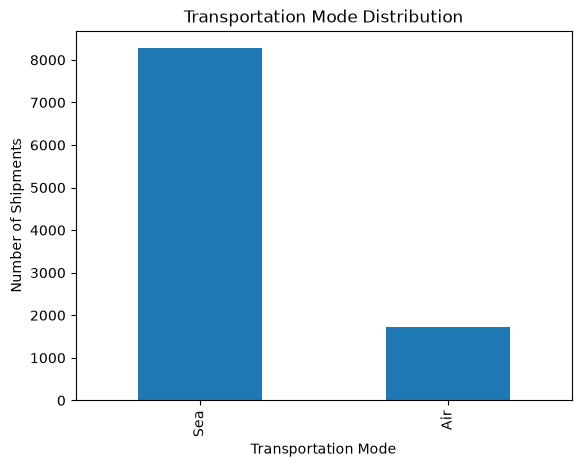

In [12]:
df["Transportation_Mode"].value_counts().plot(kind='bar')

plt.title("Transportation Mode Distribution")
plt.xlabel("Transportation Mode")
plt.ylabel("Number of Shipments")

plt.show()

In [13]:
type(df)

pandas.DataFrame

In [14]:
type(df["Transportation_Mode"])

pandas.Series

In [15]:
df.columns


Index(['Order_ID', 'Order_Date', 'Origin_City', 'Destination_City',
       'Route_Type', 'Transportation_Mode', 'Product_Category',
       'Base_Lead_Time_Days', 'Scheduled_Lead_Time_Days',
       'Actual_Lead_Time_Days', 'Delay_Days', 'Delivery_Status',
       'Disruption_Event', 'Geopolitical_Risk_Index', 'Weather_Severity_Index',
       'Inflation_Rate_Pct', 'Shipping_Cost_USD', 'Order_Weight_Kg',
       'Mitigation_Action_Taken', 'Order_Month', 'Order_DayOfWeek'],
      dtype='str')

In [16]:
df["Delivery_Status"].unique()

<StringArray>
['On Time', 'Late']
Length: 2, dtype: str

In [17]:
df["Transportation_Mode"].unique()

<StringArray>
['Sea', 'Air']
Length: 2, dtype: str

In [18]:
df["Route_Type"].unique()

<StringArray>
['Pacific', 'Intra-Asia', 'Suez', 'Commodity', 'Atlantic']
Length: 5, dtype: str

In [19]:
df["Product_Category"].unique()

<StringArray>
[            'Textiles',      'Pharmaceuticals',       'Semiconductors',
 'Consumer Electronics',        'Raw Materials',           'Auto Parts',
     'Perishable Foods']
Length: 7, dtype: str

In [20]:
pd.crosstab(df["Transportation_Mode"], df["Delivery_Status"])

Delivery_Status,Late,On Time
Transportation_Mode,,
Air,211,1518
Sea,1079,7192


In [21]:
pd.crosstab(
    df["Transportation_Mode"],
    df["Delivery_Status"],
    normalize="index"
) * 100

Delivery_Status,Late,On Time
Transportation_Mode,,
Air,12.203586,87.796414
Sea,13.045581,86.954419


In [22]:
features = [
    "Order_Date",
    "Origin_City",
    "Destination_City",
    "Route_Type",
    "Transportation_Mode", 
    "Product_Category",
    "Base_Lead_Time_Days",
    "Scheduled_Lead_Time_Days",
    
]

In [23]:
features = [
    "Origin_City",
    "Destination_City",
    "Route_Type",
    "Transportation_Mode", 
    "Product_Category",
    "Base_Lead_Time_Days",
    "Scheduled_Lead_Time_Days",
    "Geopolitical_Risk_Index",
    "Weather_Severity_Index",
    "Inflation_Rate_Pct",
    "Shipping_Cost_USD",
    "Order_Weight_Kg",
    "Order_Month",
    "Order_DayOfWeek",
]

In [24]:
print(features)

['Origin_City', 'Destination_City', 'Route_Type', 'Transportation_Mode', 'Product_Category', 'Base_Lead_Time_Days', 'Scheduled_Lead_Time_Days', 'Geopolitical_Risk_Index', 'Weather_Severity_Index', 'Inflation_Rate_Pct', 'Shipping_Cost_USD', 'Order_Weight_Kg', 'Order_Month', 'Order_DayOfWeek']


In [25]:
X = df[features]

In [26]:
y = df["Delivery_Status"]

In [27]:
type(X)
type(y)

pandas.Series

In [28]:
type(X)

pandas.DataFrame

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 14)
(2000, 14)
(8000,)
(2000,)


In [32]:
print(type(X_train))
print(type(y_train))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Origin_City",
    "Destination_City",
    "Route_Type",
    "Transportation_Mode",
    "Product_Category"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("Goose", OneHotEncoder(handle_unknown = "ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [34]:
X_train_processed = preprocessor.fit_transform(X_train)

In [35]:
type(X_train_processed)

numpy.ndarray

In [36]:
X_train_processed.shape

(8000, 35)

In [37]:
X_test_processed = preprocessor.transform(X_test)

In [38]:
X_test_processed.shape

(2000, 35)

In [39]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42, max_depth=3
)

model.fit(X_train_processed, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [40]:
df["Order_Date"].head()

0   2024-04-05
1   2024-09-08
2   2025-01-28
3   2025-02-04
4   2025-05-20
Name: Order_Date, dtype: datetime64[us]

In [41]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [42]:
df["Order_Date"].head()


0   2024-04-05
1   2024-09-08
2   2025-01-28
3   2025-02-04
4   2025-05-20
Name: Order_Date, dtype: datetime64[us]

In [43]:
y_pred = model.predict(X_test_processed)

In [44]:
print(type(y_pred))
print(y_pred.shape)

<class 'numpy.ndarray'>
(2000,)


In [45]:
print(y_pred[:10])

['On Time' 'On Time' 'On Time' 'On Time' 'On Time' 'On Time' 'On Time'
 'On Time' 'On Time' 'On Time']


In [46]:
y_pred = model.predict(X_test_processed)

print(y_pred[:5])
print(y_test.iloc[:5].values)

['On Time' 'On Time' 'On Time' 'On Time' 'On Time']
<StringArray>
['On Time', 'On Time', 'On Time', 'On Time', 'On Time']
Length: 5, dtype: str


In [47]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.8805


In [48]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 88.05%


In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[  15  238]
 [   1 1746]]


In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Late       0.94      0.06      0.11       253
     On Time       0.88      1.00      0.94      1747

    accuracy                           0.88      2000
   macro avg       0.91      0.53      0.52      2000
weighted avg       0.89      0.88      0.83      2000



In [51]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

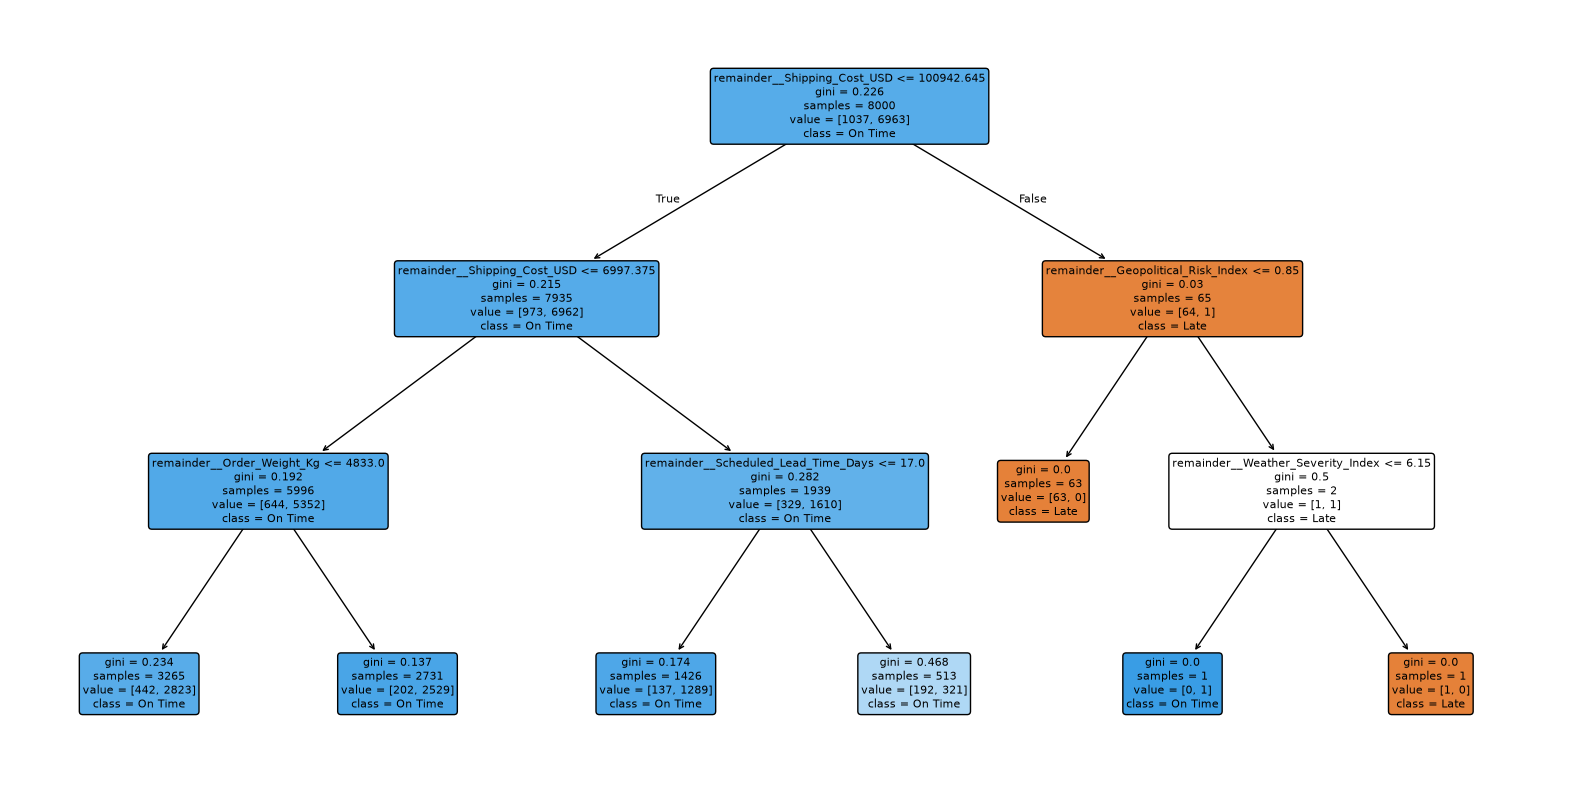

In [52]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    filled=True,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=model.classes_,
    rounded=True,
    fontsize=8
)

plt.show()

In [53]:
print(model.classes_)

['Late' 'On Time']


In [56]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
31,remainder__Shipping_Cost_USD,0.599549
27,remainder__Scheduled_Lead_Time_Days,0.326688
32,remainder__Order_Weight_Kg,0.062746
29,remainder__Weather_Severity_Index,0.005594
28,remainder__Geopolitical_Risk_Index,0.005422
0,"Goose__Origin_City_Hamburg, DE",0.000000
1,"Goose__Origin_City_Mumbai, IN",0.000000
2,"Goose__Origin_City_Santos, BR",0.000000
3,"Goose__Origin_City_Shanghai, CN",0.000000
5,"Goose__Origin_City_Tokyo, JP",0.000000


In [57]:
df.head()

,Order_ID,Order_Date,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,...,Delivery_Status,Disruption_Event,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Mitigation_Action_Taken,Order_Month,Order_DayOfWeek
0,ORD-00BCB25B,2024-04-05,"Shanghai, CN","Los Angeles, US",Pacific,Sea,Textiles,18,21,18,...,On Time,NaN,0.81,8.9,1.83,1611.81,1781,Standard Shipping,4,4
1,ORD-EBDBACB7,2024-09-08,"Tokyo, JP","Singapore, SG",Intra-Asia,Air,Pharmaceuticals,2,5,2,...,On Time,NaN,0.70,5.9,2.44,76127.70,8142,Standard Shipping,9,6
2,ORD-4052DA06,2025-01-28,"Shenzhen, CN","Rotterdam, NL",Suez,Air,Semiconductors,3,4,4,...,On Time,NaN,0.46,8.1,3.86,13699.18,1706,Standard Shipping,1,1
3,ORD-03F41ABB,2025-02-04,"Santos, BR","Shanghai, CN",Commodity,Sea,Consumer Electronics,35,36,35,...,On Time,NaN,0.88,9.3,1.58,5448.24,5796,Standard Shipping,2,1
4,ORD-347A88A6,2025-05-20,"Hamburg, DE","New York, US",Atlantic,Sea,Raw Materials,12,13,12,...,On Time,NaN,0.55,2.9,3.12,1215.98,1569,Standard Shipping,5,1


In [58]:
features


['Origin_City',
 'Destination_City',
 'Route_Type',
 'Transportation_Mode',
 'Product_Category',
 'Base_Lead_Time_Days',
 'Scheduled_Lead_Time_Days',
 'Geopolitical_Risk_Index',
 'Weather_Severity_Index',
 'Inflation_Rate_Pct',
 'Shipping_Cost_USD',
 'Order_Weight_Kg',
 'Order_Month',
 'Order_DayOfWeek']

In [59]:
train_accuracy = model.score(X_train_processed, y_train)
test_accuracy = model.score(X_test_processed, y_test)

print("Training accuracy:", train_accuracy)
print("Testing accuracy:", test_accuracy)

Training accuracy: 0.878375
Testing accuracy: 0.8805


In [ ]:
print(model)

DecisionTreeClassifier(max_depth=3, random_state=42)


In [61]:
print(model.get_depth())
print(model.get_n_leaves())

3
7


In [62]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_processed)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Late       0.94      0.06      0.11       253
     On Time       0.88      1.00      0.94      1747

    accuracy                           0.88      2000
   macro avg       0.91      0.53      0.52      2000
weighted avg       0.89      0.88      0.83      2000



In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score, accuracy_score

depths = [2, 3, 5, 7, 10, None]

results = []

for depth in depths:

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train_processed, y_train)

    y_pred = tree.predict(X_test_processed)

    accuracy = accuracy_score(y_test, y_pred)
    late_recall = recall_score(
        y_test,
        y_pred,
        pos_label="Late"
    )

    results.append({
        "max_depth": depth,
        "accuracy": accuracy,
        "late_recall": late_recall
    })

results

[{'max_depth': 2, 'accuracy': 0.881, 'late_recall': 0.06324110671936758},
 {'max_depth': 3, 'accuracy': 0.8805, 'late_recall': 0.05928853754940711},
 {'max_depth': 5, 'accuracy': 0.9035, 'late_recall': 0.2845849802371542},
 {'max_depth': 7, 'accuracy': 0.92, 'late_recall': 0.4782608695652174},
 {'max_depth': 10, 'accuracy': 0.925, 'late_recall': 0.5731225296442688},
 {'max_depth': None, 'accuracy': 0.911, 'late_recall': 0.6758893280632411}]

In [64]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score

depths = [2, 3, 5, 7, 10, None]

results = []

for depth in depths:

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train_processed, y_train)

    train_pred = tree.predict(X_train_processed)
    test_pred = tree.predict(X_test_processed)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    train_recall = recall_score(
        y_train,
        train_pred,
        pos_label="Late"
    )

    test_recall = recall_score(
        y_test,
        test_pred,
        pos_label="Late"
    )

    results.append({
        "max_depth": depth,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "train_late_recall": train_recall,
        "test_late_recall": test_recall
    })

pd.DataFrame(results)

,max_depth,train_accuracy,test_accuracy,train_late_recall,test_late_recall
0,2.0,0.878250,0.8810,0.061716,0.063241
1,3.0,0.878375,0.8805,0.061716,0.059289
2,5.0,0.906000,0.9035,0.298939,0.284585
3,7.0,0.926375,0.9200,0.473481,0.478261
4,10.0,0.949000,0.9250,0.633558,0.573123
5,NaN,1.000000,0.9110,1.000000,0.675889


In [65]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score

split_values = [2, 5, 10, 20, 50]

results_split = []

for min_split in split_values:

    tree = DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=min_split,
        random_state=42
    )

    tree.fit(X_train_processed, y_train)

    train_pred = tree.predict(X_train_processed)
    test_pred = tree.predict(X_test_processed)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    train_recall = recall_score(
        y_train,
        train_pred,
        pos_label="Late"
    )

    test_recall = recall_score(
        y_test,
        test_pred,
        pos_label="Late"
    )

    results_split.append({
        "min_samples_split": min_split,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "train_late_recall": train_recall,
        "test_late_recall": test_recall
    })

pd.DataFrame(results_split)

,min_samples_split,train_accuracy,test_accuracy,train_late_recall,test_late_recall
0,2,0.949000,0.9250,0.633558,0.573123
1,5,0.948000,0.9210,0.632594,0.565217
2,10,0.945375,0.9195,0.623915,0.565217
3,20,0.942500,0.9210,0.614272,0.573123
4,50,0.937125,0.9175,0.610415,0.588933


In [66]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score

leaf_values = [1, 2, 5, 10, 20]

results_leaf = []

for min_leaf in leaf_values:

    tree = DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=min_leaf,
        random_state=42
    )

    tree.fit(X_train_processed, y_train)

    train_pred = tree.predict(X_train_processed)
    test_pred = tree.predict(X_test_processed)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    train_recall = recall_score(
        y_train,
        train_pred,
        pos_label="Late"
    )

    test_recall = recall_score(
        y_test,
        test_pred,
        pos_label="Late"
    )

    results_leaf.append({
        "min_samples_leaf": min_leaf,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "train_late_recall": train_recall,
        "test_late_recall": test_recall
    })

pd.DataFrame(results_leaf)

,min_samples_leaf,train_accuracy,test_accuracy,train_late_recall,test_late_recall
0,1,0.949000,0.9250,0.633558,0.573123
1,2,0.946875,0.9155,0.634523,0.573123
2,5,0.941625,0.9185,0.616201,0.569170
3,10,0.938000,0.9310,0.594021,0.592885
4,20,0.929625,0.9230,0.574735,0.561265


In [67]:
final_tree = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

final_tree.fit(X_train_processed, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [68]:
y_pred_final = final_tree.predict(X_test_processed)

In [69]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

        Late       0.81      0.59      0.68       253
     On Time       0.94      0.98      0.96      1747

    accuracy                           0.93      2000
   macro avg       0.88      0.79      0.82      2000
weighted avg       0.93      0.93      0.93      2000



In [70]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

print(cm)

[[ 150  103]
 [  35 1712]]


In [71]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [72]:
y_pred_rf = rf_model.predict(X_test_processed)

In [73]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

        Late       0.96      0.21      0.35       253
     On Time       0.90      1.00      0.95      1747

    accuracy                           0.90      2000
   macro avg       0.93      0.61      0.65      2000
weighted avg       0.91      0.90      0.87      2000



In [74]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[  54  199]
 [   2 1745]]


In [75]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_balanced.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [76]:
y_pred_rf_balanced = rf_balanced.predict(X_test_processed)

print(classification_report(y_test, y_pred_rf_balanced))

              precision    recall  f1-score   support

        Late       0.86      0.30      0.45       253
     On Time       0.91      0.99      0.95      1747

    accuracy                           0.91      2000
   macro avg       0.89      0.65      0.70      2000
weighted avg       0.90      0.91      0.88      2000



In [77]:
cm_rf_balanced = confusion_matrix(
    y_test,
    y_pred_rf_balanced
)

print(cm_rf_balanced)

[[  76  177]
 [  12 1735]]


In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score

tree_counts = [50, 100, 200, 300]

rf_results = []

for n in tree_counts:

    rf = RandomForestClassifier(
        n_estimators=n,
        class_weight="balanced",
        random_state=42
    )

    rf.fit(X_train_processed, y_train)

    y_pred = rf.predict(X_test_processed)

    accuracy = accuracy_score(y_test, y_pred)

    late_recall = recall_score(
        y_test,
        y_pred,
        pos_label="Late"
    )

    rf_results.append({
        "n_estimators": n,
        "accuracy": accuracy,
        "late_recall": late_recall
    })

pd.DataFrame(rf_results)

,n_estimators,accuracy,late_recall
0,50,0.9010,0.296443
1,100,0.9055,0.300395
2,200,0.9065,0.296443
3,300,0.9055,0.292490


In [79]:
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

rf_tuned.fit(X_train_processed, y_train)

y_pred_rf_tuned = rf_tuned.predict(X_test_processed)

print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

        Late       0.37      0.49      0.42       253
     On Time       0.92      0.88      0.90      1747

    accuracy                           0.83      2000
   macro avg       0.65      0.68      0.66      2000
weighted avg       0.85      0.83      0.84      2000



In [80]:
cm_rf_tuned = confusion_matrix(
    y_test,
    y_pred_rf_tuned
)

print(cm_rf_tuned)

[[ 124  129]
 [ 211 1536]]


In [81]:
tree_importance = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Decision_Tree": final_tree.feature_importances_,
    "Random_Forest": rf_tuned.feature_importances_
})

In [82]:
tree_importance = tree_importance.sort_values(
    by="Decision_Tree",
    ascending=False
)

tree_importance.head(10)

,Feature,Decision_Tree,Random_Forest
31,remainder__Shipping_Cost_USD,0.458440,0.336561
32,remainder__Order_Weight_Kg,0.258024,0.133299
28,remainder__Geopolitical_Risk_Index,0.139402,0.076645
27,remainder__Scheduled_Lead_Time_Days,0.087907,0.050651
26,remainder__Base_Lead_Time_Days,0.034775,0.021999
30,remainder__Inflation_Rate_Pct,0.005324,0.074540
17,Goose__Transportation_Mode_Air,0.004981,0.012943
29,remainder__Weather_Severity_Index,0.003553,0.070496
16,Goose__Route_Type_Suez,0.003448,0.008294
33,remainder__Order_Month,0.002192,0.055681
